In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


cyberattack_data = pd.read_csv("incribo.csv")
cyberattack_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               40000 non-null  object 
 1   Source IP Address       40000 non-null  object 
 2   Destination IP Address  40000 non-null  object 
 3   Source Port             40000 non-null  int64  
 4   Destination Port        40000 non-null  int64  
 5   Protocol                40000 non-null  object 
 6   Packet Length           40000 non-null  int64  
 7   Packet Type             40000 non-null  object 
 8   Traffic Type            40000 non-null  object 
 9   Payload Data            40000 non-null  object 
 10  Malware Indicators      20000 non-null  object 
 11  Anomaly Scores          40000 non-null  float64
 12  Alerts/Warnings         19933 non-null  object 
 13  Attack Type             40000 non-null  object 
 14  Attack Signature        40000 non-null

In [2]:
cyberattack_data.rename(columns={
    "Timestamp": "timestamp", 
    "Source IP Address": "src_ip_address", 
    "Destination IP Address": "dest_ip_address",
    "Source Port": "src_port",
    "Destination Port": "dest_port",
    "Protocol": "protocol",
    "Packet Length": "packet_len",
    "Packet Type": "packet_type",
    "Traffic Type": "traffic_type",
    "Payload Data": "payload_data",
    "Malware Indicators": "malware_indicators",
    "Anomaly Scores": "anomaly_scores",
    "Alerts/Warnings": "alerts/warnings",
    "Attack Type": "attack_type",
    "Attack Signature": "attack_signature",
    "Action Taken": "action_taken",
    "Severity Level": "severity_level",
    "User Information": "user_info",
    "Device Information": "device_info",
    "Network Segment": "network_segment",
    "Geo-location Data": "geo_location_data",
    "Proxy Information": "proxy_info",
    "Firewall Logs": "firewall_logs",
    "IDS/IPS Alerts": "ids/ips_alerts",
    "Log Source": "log_src"}, inplace=True)
cyberattack_data["timestamp"] = pd.to_datetime(cyberattack_data["timestamp"])
cyberattack_data = cyberattack_data.set_index("timestamp")
cyberattack_data = cyberattack_data.map(lambda x: x.lower() if type(x) == str else x)
cyberattack_data.sample(5)

,src_ip_address,dest_ip_address,src_port,dest_port,protocol,packet_len,packet_type,traffic_type,payload_data,malware_indicators,...,action_taken,severity_level,user_info,device_info,network_segment,geo_location_data,proxy_info,firewall_logs,ids/ips_alerts,log_src
timestamp,,,,,,,,,,,,,,,,,,,,,
2021-12-19 02:51:03,21.72.19.131,216.27.98.67,23613,39333,udp,1437,data,http,iusto error cumque quod distinctio.\ncorrupti ...,NaN,...,ignored,medium,gatik balakrishnan,mozilla/5.0 (compatible; msie 6.0; windows nt ...,segment a,"nadiad, assam",93.150.120.44,log data,NaN,server
2022-09-04 22:12:11,87.173.86.42,202.144.159.99,11008,37565,udp,773,control,dns,quidem dolorum saepe repudiandae quo. voluptat...,NaN,...,logged,high,neelofar buch,mozilla/5.0 (macintosh; u; ppc mac os x 10_12_...,segment a,"ambarnath, assam",NaN,NaN,alert data,firewall
2020-12-16 02:01:08,187.27.0.95,29.45.201.32,50352,60345,tcp,73,control,dns,fugiat eos vel ullam dolor. eos eaque amet qua...,ioc detected,...,ignored,medium,lagan setty,mozilla/5.0 (compatible; msie 7.0; windows nt ...,segment a,"pimpri-chinchwad, manipur",192.21.101.228,NaN,alert data,firewall
2020-11-04 06:20:23,119.67.135.78,164.212.168.110,30418,47121,tcp,431,data,http,maiores cupiditate temporibus voluptatibus nul...,ioc detected,...,blocked,medium,arnav gola,mozilla/5.0 (ipod; u; cpu iphone os 3_1 like m...,segment c,"kakinada, uttarakhand",NaN,log data,NaN,firewall
2021-08-27 02:08:08,148.136.233.250,45.76.235.148,46576,14687,udp,1088,data,ftp,id necessitatibus dolorem laboriosam minus bea...,NaN,...,logged,low,sahil sengupta,mozilla/5.0 (windows 95) applewebkit/532.0 (kh...,segment b,"medininagar, telangana",90.202.175.247,NaN,alert data,firewall


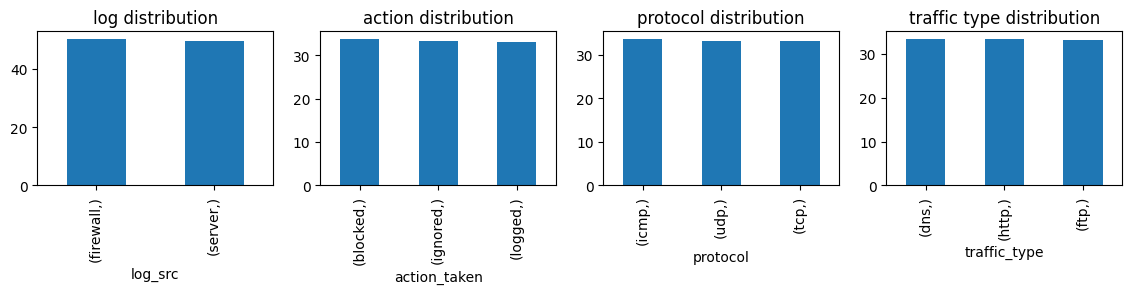

In [3]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(14, 2))
# log distribution
log_distribution = cyberattack_data.value_counts(subset=["log_src"], normalize=True).mul(100).round(1)
log_distribution.plot(kind="bar", ax=ax[0])
# action distribution
action_distribution = cyberattack_data.value_counts(subset=["action_taken"], normalize=True).mul(100).round(1)
action_distribution.plot(kind="bar", ax=ax[1])
# protocol distribution
protocol_distribution = cyberattack_data.value_counts(subset=["protocol"], normalize=True).mul(100).round(1)
protocol_distribution.plot(kind="bar", ax=ax[2])
# traffic type distribution
traffic_distribution = cyberattack_data.value_counts(subset=["traffic_type"], normalize=True).mul(100).round(1)
traffic_distribution.plot(kind="bar", ax=ax[3])
ax[0].set_title("log distribution")
ax[0].set_ylabel(None)
ax[1].set_title("action distribution")
ax[1].set_ylabel(None)
ax[2].set_title("protocol distribution")
ax[2].set_ylabel(None)
ax[3].set_title("traffic type distribution")
ax[3].set_ylabel(None)
# tells us nothing useful
plt.show()

<Axes: xlabel='month', ylabel='count'>

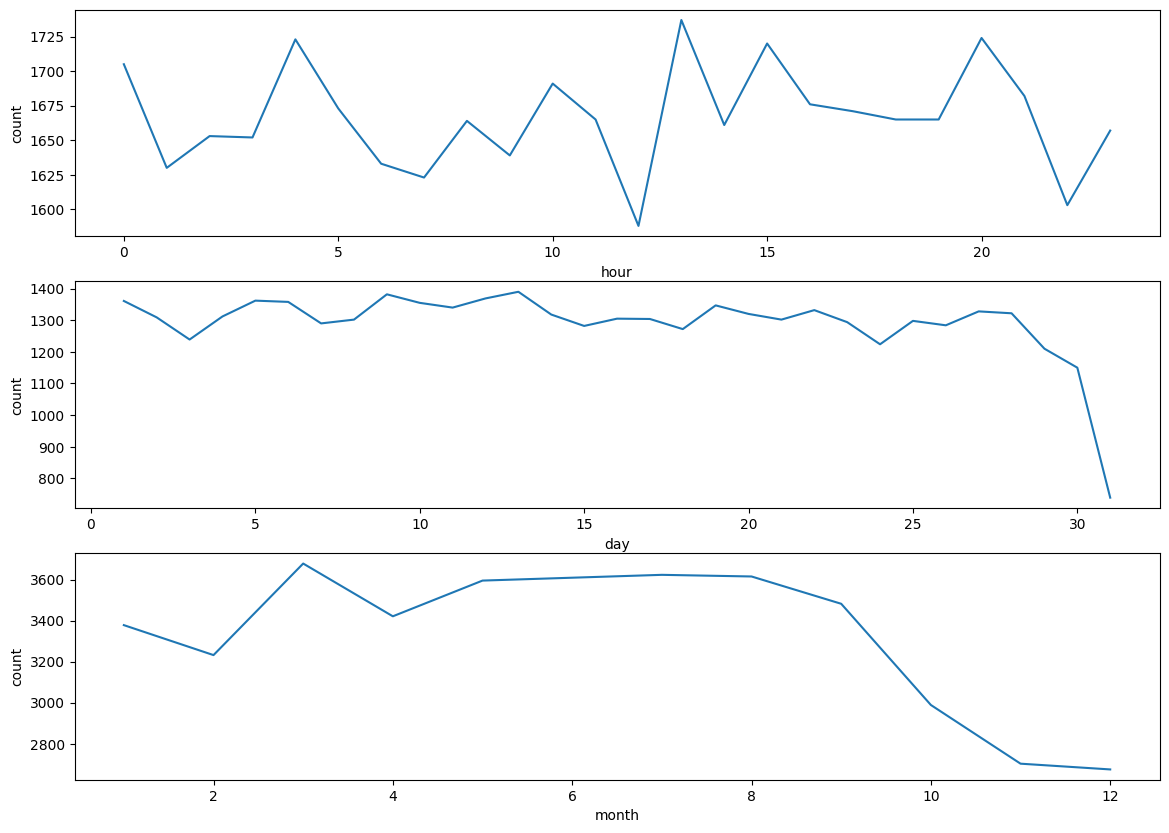

In [4]:
# temporal buckets
events = cyberattack_data.copy()
events["hour"] = events.index.hour
events["day"] = events.index.day
events["month"] = events.index.month
hourly_events = events.value_counts(subset=["hour"]).sort_index().to_frame()
hourly_events = hourly_events.reset_index()
daily_events = events.value_counts(subset=["day"]).sort_index().to_frame()
daily_events = daily_events.reset_index()
monthly_events = events.value_counts(subset=["month"]).sort_index().to_frame()
monthly_events = monthly_events.reset_index()
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(14, 10))
sns.lineplot(x="hour", y="count", data=hourly_events, ax=ax[0])
sns.lineplot(x="day", y="count", data=daily_events, ax=ax[1])
sns.lineplot(x="month", y="count", data=monthly_events, ax=ax[2])

In [5]:
# severity 
severity_distribution = cyberattack_data.value_counts(subset=["severity_level"], normalize=True).mul(100).round(1)
# artificial dataset so its a balanced distribution...
severity_distribution.head()

severity_level
medium            33.6
high              33.5
low               33.0
Name: proportion, dtype: float64

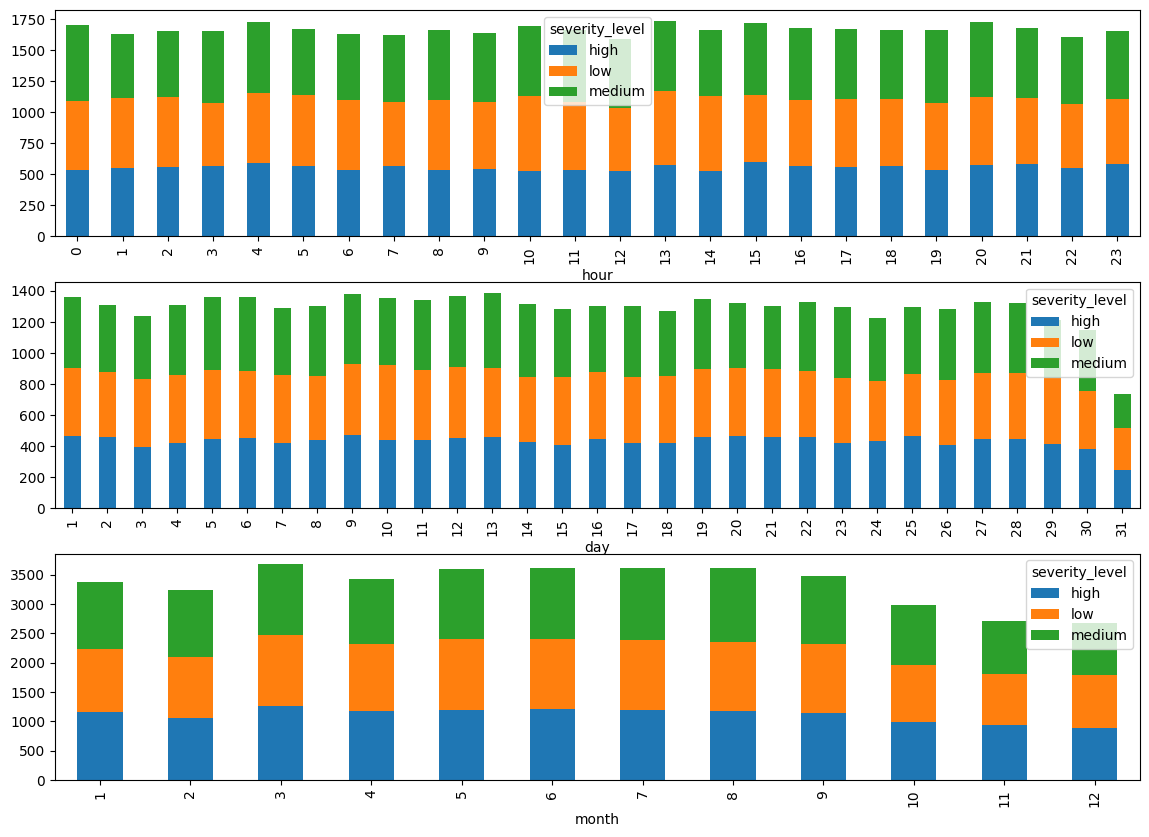

In [6]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(14, 10))
# temporal bucket severity
severities_by_hour = events.value_counts(subset=["hour", "severity_level"]).unstack(fill_value=0)
severities_by_hour.plot(kind="bar", stacked=True, ax=ax[0])
severities_by_day = events.value_counts(subset=["day", "severity_level"]).unstack(fill_value=0)
severities_by_day.plot(kind="bar", stacked=True, ax=ax[1])
severities_by_month = events.value_counts(subset=["month", "severity_level"]).unstack(fill_value=0)
severities_by_month.plot(kind="bar", stacked=True, ax=ax[2])
plt.show()

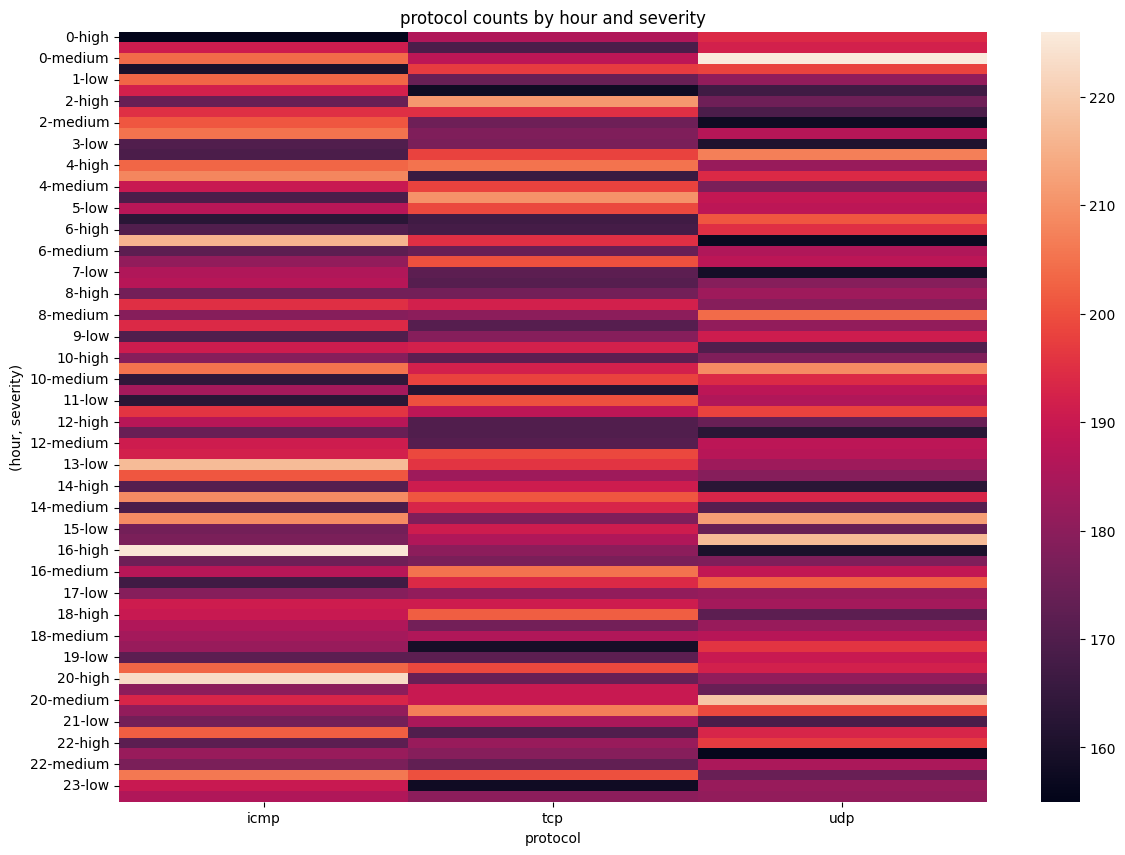

In [7]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(14, 10))
# temporal bucket severity with protocol
protocol_severities_by_hour = events.value_counts(subset=["hour", "severity_level", "protocol"]).unstack(fill_value=0)
# plotting one severity at time would probably be cleaner...
sns.heatmap(protocol_severities_by_hour, annot=False)
plt.title("protocol counts by hour and severity")
plt.xlabel("protocol")
plt.ylabel("(hour, severity)")
plt.show()